<a href="https://colab.research.google.com/github/azadeh-3880/skills-github-pages/blob/ai-test/fmnist96_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import tensorflow as tf
from tensorflow import keras
keras.__version__
fmnist_data=keras.datasets.fashion_mnist
(x_train, y_train), (x_test, y_test)=fmnist_data.load_data()
import matplotlib.pyplot as plt
import numpy as np

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


#normalize

In [ ]:
x_train,x_test=x_train/255,x_test/255

In [ ]:
x_train.shape

(60000, 28, 28)

#model ann

In [ ]:
model = keras.Sequential(
    [
        keras.layers.Flatten(input_shape=[28,28]),
       keras.layers.Dense(120, activation="relu"),
        keras.layers.Dense(75, activation="relu"),
        keras.layers.Dense(10,activation="softmax"),
    ]
)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 120)                 │          94,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 75)                  │           9,075 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 10)                  │             760 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 104,035 (406.39 KB)

 Trainable params: 104,035 (406.39 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.layers

[<Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dense name=dense_1, built=True>,
 <Dense name=dense_2, built=True>]

In [ ]:
weights,bias=model.layers[1].get_weights()

In [ ]:
weights



array([[-0.03973288, -0.0527635 ,  0.0717507 , ..., -0.0336713 ,
         0.037255  , -0.00910279],
       [-0.01252171,  0.02477698, -0.00369988, ..., -0.02042956,
        -0.0056043 , -0.0141707 ],
       [ 0.0109723 ,  0.00478514, -0.0575325 , ...,  0.05060966,
         0.05409493,  0.05111735],
       ...,
       [ 0.0494515 , -0.02622832, -0.0789309 , ..., -0.02605743,
         0.04296112,  0.07415363],
       [-0.02896484, -0.03256085,  0.07938485, ..., -0.00395157,
        -0.03112503,  0.03098021],
       [ 0.03331997, -0.07958478, -0.0232151 , ...,  0.05763935,
        -0.00250581, -0.02822245]], dtype=float32)

In [ ]:
bias

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0.], dtype=float32)

#compile model

In [ ]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])

#model fit

In [ ]:
history=model.fit(x_train,y_train,epochs=50,validation_split=0.15)

Epoch 1/50
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7679 - loss: 0.6559 - val_accuracy: 0.8466 - val_loss: 0.4201
Epoch 2/50
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8607 - loss: 0.3848 - val_accuracy: 0.8694 - val_loss: 0.3633
Epoch 3/50
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8750 - loss: 0.3402 - val_accuracy: 0.8718 - val_loss: 0.3486
Epoch 4/50
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8849 - loss: 0.3130 - val_accuracy: 0.8752 - val_loss: 0.3427
Epoch 5/50
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8925 - loss: 0.2931 - val_accuracy: 0.8771 - val_loss: 0.3308
Epoch 6/50
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9000 - loss: 0.2754 - val_accuracy: 0.8846 - val_loss: 0.3179
Epoch 7/50
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8988 - loss: 0.2692 - val_accuracy: 0.8788 - val_loss: 0.3370
Epoch 8/50
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9024 - loss: 0.2577 -

#plot output

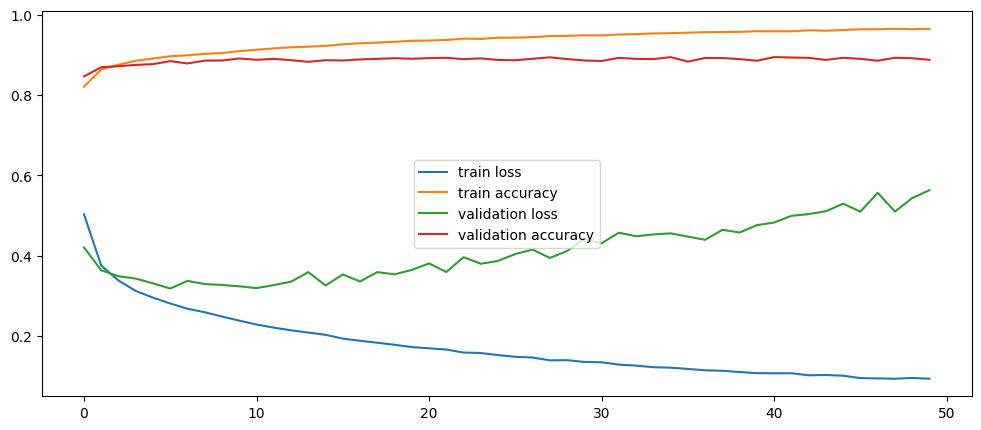

In [ ]:
fig,ax=plt.subplots(figsize=(12,5))
ax.plot(history.history["loss"],label="train loss")
ax.plot(history.history["accuracy"],label="train accuracy")
ax.plot(history.history["val_loss"],label="validation loss")
ax.plot(history.history["val_accuracy"],label="validation accuracy")
ax.legend()

#evaluate model






In [ ]:
model.evaluate(x_test,y_test,verbose=0)

[0.6020269989967346, 0.8863999843597412]

In [ ]:
x3=x_test[1:5,:,:]
x3.shape

(4, 28, 28)

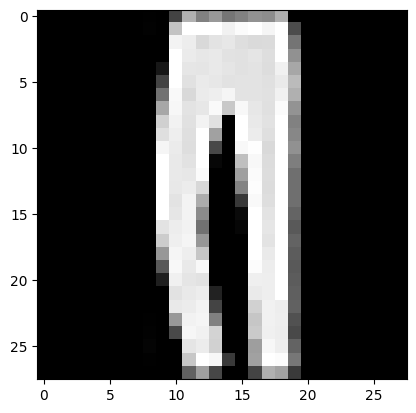

In [ ]:
plt.imshow(x3[1],cmap="gray")

In [ ]:
model.predict(x3).round(3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


array([[0.   , 0.   , 1.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.   ],
       [0.   , 1.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.   ],
       [0.   , 1.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.   ],
       [0.754, 0.   , 0.   , 0.   , 0.   , 0.   , 0.246, 0.   , 0.   ,
        0.   ]], dtype=float32)

In [ ]:
model.predict(x3).shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


(4, 10)

In [ ]:
np.argmax(model.predict(x3).round(3),axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


array([2, 1, 1, 0])

In [ ]:
y_test[1:5]

array([2, 1, 1, 6], dtype=uint8)